# Advanced Developer Cluster Analysis — ADV_Clustering_Dev

This notebook is a direct extension of `DeveloperClustering.ipynb`. It reads the `developer_features` table that was built in the base notebook and layers on six additional capabilities:

1. **Advanced Feature Engineering** — six derived features that capture *engagement velocity*, *activity breadth vs. depth*, *community involvement*, *technical depth*, and *organizational affiliation strength*
2. **Multi-Metric Cluster Validation** — four complementary cluster quality metrics (Inertia, Silhouette, Davies-Bouldin, Calinski-Harabasz) plotted together to justify the choice of `k = 4`
3. **Clustering Algorithm Comparison** — K-Means, Gaussian Mixture Models (GMM), and Agglomerative Hierarchical Clustering evaluated on an identical 5 k sample so results are directly comparable
4. **t-SNE Visualization** — a non-linear dimensionality reduction that reveals cluster topology far more faithfully than PCA alone
5. **Rich Tier Profiling** — spider/radar chart, violin plots, normalized centroid heatmap, and a stacked activity-composition bar chart
6. **Deep Actionable Insights** — F-statistic feature importance, per-developer engagement-gap analysis, and tier distribution broken down by organization type

**Prerequisites:** `Cleaning_Final.ipynb` must be run first; the `developer_features` table in `developer_project.duckdb` must already exist (produced by Section 1 of `DeveloperClustering.ipynb`).

**Re-running:** Kernel → Restart & Clear Output → Run All

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import f_oneway

con = duckdb.connect('developer_project.duckdb')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

SEED = 42
N_CLUSTERS = 4
TIER_ORDER  = ['beginner', 'experienced', 'advanced', 'enterprise']
TIER_COLORS = {
    'beginner':   '#90CAF9',
    'experienced':'#66BB6A',
    'advanced':   '#FFA726',
    'enterprise': '#EF5350',
}

FEATURE_COLS = [
    'total_activities', 'total_score', 'avg_score', 'max_score',
    'distinct_activity_types', 'high_value_activities', 'presenter_activities',
    'dli_count', 'dli_instructor_led', 'dli_self_paced',
    'api_count', 'container_count', 'model_count', 'helm_count', 'ngc_downloads',
    'conference_count', 'forum_count', 'bug_count', 'hackathon_count',
    'webinar_count', 'presenter_role_count',
    'activity_span_days', 'days_since_last_activity',
    'is_enterprise', 'is_university', 'is_startup',
    'has_account', 'is_wwfo_targeted',
    'tenure_days', 'development_areas_count', 'fields_of_interest_count',
]

LOG_COLS = [
    'total_activities', 'total_score', 'dli_count', 'dli_instructor_led',
    'dli_self_paced', 'api_count', 'container_count', 'model_count',
    'helm_count', 'ngc_downloads', 'conference_count', 'forum_count',
    'bug_count', 'hackathon_count', 'webinar_count', 'presenter_role_count',
    'high_value_activities', 'presenter_activities', 'activity_span_days', 'tenure_days',
]

print('All libraries loaded successfully.')

## Section 1 — Data Loading & Validation

This section connects to `developer_project.duckdb` and loads the `developer_features` table that was materialized by the base clustering notebook. Before loading, it verifies that the table exists so the notebook fails fast with a clear error message rather than a cryptic downstream exception.

The loaded dataframe `df_raw` has one row per unique developer, with 31 feature columns covering activity counts, DLI training, API/container usage, organizational affiliation, and temporal signals (tenure, recency). This is the exact feature matrix the base notebook used — Section 2 below will add six additional engineered features on top.

In [ ]:
tables = con.execute('SHOW TABLES').df()
if 'developer_features' not in tables['name'].values:
    raise RuntimeError(
        'developer_features table not found. '
        'Run Cleaning_Final.ipynb and Section 1 of DeveloperClustering.ipynb first.'
    )

df_raw = con.execute('SELECT * FROM developer_features').df()
print(f'Loaded {len(df_raw):,} developers  |  {df_raw.shape[1]} base features')
display(df_raw[FEATURE_COLS[:10]].describe().round(2))

## Section 2 — Advanced Feature Engineering

The base notebook uses raw activity counts directly as features. While those counts carry real signal, they do not capture *how* a developer uses the platform relative to their own history, or how engaged they are per unit of time. This section engineers six derived features that encode these higher-order relationships:

| Feature | Formula | Intuition |
|---|---|---|
| `engagement_velocity` | `total_score / (activity_span_days + 1)` | Score earned per active day — separates burst users from sustained contributors |
| `breadth_ratio` | `distinct_activity_types / log(total_activities + 1)` | Measures diversity of engagement; high ratio = generalist, low = specialist |
| `community_index` | Weighted sum of forum, bug, hackathon, conference, presenter activities | Quantifies outward-facing community contribution |
| `technical_depth` | Weighted sum of instructor-led DLI, self-paced DLI, API, containers, helm, models | Quantifies depth of technical platform usage |
| `recency_score` | `1 / (days_since_last_activity + 1)` | Recency of engagement on a continuous scale; higher = more recently active |
| `org_score` | Weighted sum of enterprise, university, startup, and WWFO flags | Composite organizational affiliation strength |

The weights are intentional: instructor-led DLI (4×) and hackathon participation (5×) outweigh simpler activities because they represent far greater time investment and NVIDIA engagement value.

In [ ]:
df = df_raw.copy()

# Score earned per active calendar day — rewards sustained engagement over one-off spikes
df['engagement_velocity'] = df['total_score'] / (df['activity_span_days'] + 1)

# How diverse vs. deep activity is — log-normalised against total activity volume
df['breadth_ratio'] = df['distinct_activity_types'] / (np.log1p(df['total_activities']) + 1e-6)

# Outward-facing community contribution index
df['community_index'] = (
    df['forum_count']         * 3 +
    df['bug_count']           * 2 +
    df['hackathon_count']     * 5 +
    df['conference_count']    * 2 +
    df['presenter_role_count']* 5
)

# Depth of technical platform usage
df['technical_depth'] = (
    df['dli_instructor_led'] * 4 +
    df['dli_self_paced']     * 2 +
    df['api_count']          * 1 +
    df['container_count']    * 1 +
    df['helm_count']         * 2 +
    df['model_count']        * 1
)

# Recency as a continuous signal (higher = active more recently)
df['recency_score'] = 1.0 / (df['days_since_last_activity'] + 1)

# Composite organizational affiliation score
df['org_score'] = (
    df['is_enterprise']   * 3 +
    df['is_university']   * 2 +
    df['is_startup']      * 1 +
    df['is_wwfo_targeted']* 2
)

NEW_FEATURES = [
    'engagement_velocity', 'breadth_ratio', 'community_index',
    'technical_depth', 'recency_score', 'org_score',
]
ADV_FEATURE_COLS = FEATURE_COLS + NEW_FEATURES
ADV_LOG_COLS = LOG_COLS + ['engagement_velocity', 'community_index', 'technical_depth']

print(f'Base features: {len(FEATURE_COLS)}  |  New features: {len(NEW_FEATURES)}  |  Total: {len(ADV_FEATURE_COLS)}')
display(df[NEW_FEATURES].describe().round(4))

## Section 3 — Preprocessing

Sklearn's distance-based algorithms (K-Means, Agglomerative) and the covariance-based GMM are all highly sensitive to feature scale. Without normalisation, features like `total_activities` (max ~2 million) would completely dominate features like `hackathon_count` (max 4).

Two transformations are applied in sequence:

1. **Log1p transform** on all count-based columns (`ADV_LOG_COLS`). This compresses the extreme right tail produced by power-law activity distributions while preserving zero values (`log(1+0) = 0`). `recency_score` is additionally scaled by 1,000 before log-transforming because its raw values are tiny fractions that would otherwise cluster near zero after scaling.

2. **StandardScaler** (zero mean, unit variance) on the fully log-transformed matrix. This ensures that every feature contributes equally to distance calculations regardless of its original magnitude.

The resulting `X_scaled` matrix (shape ≈ 9.3 M × 37) is what all clustering algorithms receive.

In [ ]:
X_raw = df[ADV_FEATURE_COLS].copy()

X = X_raw.copy()
for col in ADV_LOG_COLS:
    X[col] = np.log1p(X[col].clip(lower=0))
X['days_since_last_activity'] = np.log1p(X['days_since_last_activity'])
# Scale recency before log so the tiny fractions are spread across a meaningful range
X['recency_score'] = np.log1p(X['recency_score'] * 1000)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

assert not np.isnan(X_scaled).any(), 'NaN values found in scaled matrix!'
assert not np.isinf(X_scaled).any(), 'Inf values found in scaled matrix!'

print(f'Preprocessed matrix: {X_scaled.shape}')
print(f'NaN: {np.isnan(X_scaled).any()}  |  Inf: {np.isinf(X_scaled).any()}')
print(f'Global mean (should be ~0): {X_scaled.mean():.6f}')
print(f'Global std  (should be ~1): {X_scaled.std():.6f}')

## Section 4 — Dimensionality Reduction Analysis (PCA Scree)

Before clustering, it is useful to understand how much information is carried by the leading principal components. A **scree plot** shows the proportion of variance explained by each component individually, while the **cumulative variance curve** shows how many components are needed to retain a given fraction of total information.

This analysis serves two purposes:
1. It reveals whether the 37-feature space has significant redundancy (i.e., many features are correlated), which would make the clustering task easier by reducing the effective dimensionality.
2. It informs the t-SNE pre-reduction step in Section 8 — t-SNE works best when applied to the top-N PCA components rather than raw features, where N is chosen to retain ~90% of variance.

The analysis is run on a 30 k stratified random sample for speed; results are representative of the full 9.3 M population.

In [ ]:
np.random.seed(SEED)
sample_idx_pca = np.random.choice(len(X_scaled), size=min(30_000, len(X_scaled)), replace=False)
X_pca_sample = X_scaled[sample_idx_pca]

pca_full = PCA(n_components=20, random_state=SEED)
pca_full.fit(X_pca_sample)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained * 100, color='#4A90D9', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Explained Variance')
axes[0].set_xticks(range(1, len(explained) + 1))
for i, v in enumerate(explained * 100):
    axes[0].text(i + 1, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7)

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, marker='o', color='#E74C3C', linewidth=2)
axes[1].axhline(y=80, color='gray',   linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].fill_between(range(1, len(cumulative) + 1), cumulative * 100, alpha=0.15, color='#E74C3C')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(); axes[1].set_xticks(range(1, len(cumulative) + 1))

plt.suptitle('PCA Dimensionality Analysis (30 k sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n80 = int(np.argmax(cumulative >= 0.80)) + 1
n90 = int(np.argmax(cumulative >= 0.90)) + 1
print(f'Components for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'First 2 PCs explain:        {cumulative[1]*100:.1f}%')

## Section 5 — Optimal Cluster Count Selection

The base notebook used an elbow plot on inertia alone to justify `k = 4`. Inertia is a necessary but insufficient criterion — it always decreases as k increases, so it cannot detect when extra clusters stop adding meaningful information. This section adds three complementary metrics to build a stronger case:

| Metric | What it measures | Better direction |
|---|---|---|
| **Inertia** | Total within-cluster sum of squared distances | Lower |
| **Silhouette Score** | How similar each point is to its own cluster vs. neighbouring clusters; ranges [−1, 1] | Higher |
| **Davies-Bouldin Score** | Average ratio of within-cluster scatter to between-cluster separation | Lower |
| **Calinski-Harabasz Score** | Ratio of between-cluster dispersion to within-cluster dispersion | Higher |

All four are evaluated on the same 30 k sample for k = 2 … 8. The choice of `k = 4` is validated when multiple metrics agree — look for the elbow in inertia, the peak in silhouette, the trough in Davies-Bouldin, and the knee in Calinski-Harabasz all pointing to the same k.

In [ ]:
np.random.seed(SEED)
sample_idx_k = np.random.choice(len(X_scaled), size=min(30_000, len(X_scaled)), replace=False)
X_k = X_scaled[sample_idx_k]

results = []
print('k  |  Inertia       |  Silhouette  |  Davies-Bouldin  |  Calinski-Harabasz')
print('-' * 75)
for k in range(2, 9):
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=5, batch_size=10_000)
    lbl_k = km.fit_predict(X_k)
    sil = silhouette_score(X_k, lbl_k, sample_size=5_000, random_state=SEED)
    db  = davies_bouldin_score(X_k, lbl_k)
    ch  = calinski_harabasz_score(X_k, lbl_k)
    results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})
    marker = '  <-- chosen' if k == N_CLUSTERS else ''
    print(f'{k}  |  {km.inertia_:12.0f}  |  {sil:.4f}      |  {db:.4f}           |  {ch:.0f}{marker}')

res = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col, title, color in [
    (axes[0,0], 'inertia',           'Elbow Method — Inertia (lower=better)',               '#4A90D9'),
    (axes[0,1], 'silhouette',        'Silhouette Score (higher=better)',                     '#27AE60'),
    (axes[1,0], 'davies_bouldin',    'Davies-Bouldin Score (lower=better)',                  '#E74C3C'),
    (axes[1,1], 'calinski_harabasz', 'Calinski-Harabasz Score (higher=better)',              '#8E44AD'),
]:
    ax.plot(res['k'], res[col], marker='o', color=color, linewidth=2)
    ax.axvline(x=N_CLUSTERS, color='red', linestyle='--', alpha=0.7, label=f'k={N_CLUSTERS}')
    ax.set_xlabel('k (number of clusters)'); ax.set_ylabel(col.replace('_', ' ').title())
    ax.set_title(title); ax.legend(); ax.set_xticks(list(range(2, 9)))

plt.suptitle('Cluster Validity Metrics Across k — 30 k Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 — Clustering Algorithm Comparison

Three fundamentally different clustering algorithms are run on an identical 5 k sample and evaluated against all four validity metrics. This comparison answers the question: *does the algorithm choice matter, and if so, by how much?*

### Algorithms

**K-Means (MiniBatchKMeans)**
Assigns each point to the nearest centroid and minimises total within-cluster variance. Assumes spherical, equally sized clusters. Its main advantage is linear scalability — it is the only option that can run on all 9.3 M developers in reasonable time.

**Gaussian Mixture Model (GMM)**
Models each cluster as a multivariate Gaussian and assigns soft probabilities rather than hard labels. It can capture elliptical cluster shapes and is theoretically richer than K-Means. The `covariance_type='full'` setting allows each component to have its own covariance matrix.

**Agglomerative Hierarchical Clustering (Ward linkage)**
Builds clusters bottom-up by merging the pair of clusters that minimises the increase in total within-cluster variance (Ward criterion). It does not assume any cluster shape and produces a deterministic dendrogram. The primary limitation is O(n²) memory, which makes it impractical beyond ~10 k samples.

### Why K-Means wins at scale
GMM and Agglomerative may produce marginally better silhouette scores on the small sample, but neither algorithm can process 9.3 M records. MiniBatchKMeans processes data in mini-batches and scales linearly, making it the pragmatic choice for the full-data fit in Section 7.

In [ ]:
np.random.seed(SEED)
sample_idx_alg = np.random.choice(len(X_scaled), size=5_000, replace=False)
X_alg = X_scaled[sample_idx_alg]

algo_configs = {
    'K-Means':              MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10),
    'GMM':                  GaussianMixture(n_components=N_CLUSTERS, random_state=SEED, covariance_type='full', n_init=3),
    'Hierarchical (Ward)':  AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
}

algo_labels  = {}
algo_metrics = []

for name, model in algo_configs.items():
    lbl = model.fit_predict(X_alg)
    algo_labels[name] = lbl
    sil = silhouette_score(X_alg, lbl)
    db  = davies_bouldin_score(X_alg, lbl)
    ch  = calinski_harabasz_score(X_alg, lbl)
    algo_metrics.append({
        'Algorithm': name,
        'Silhouette (↑)':        round(sil, 4),
        'Davies-Bouldin (↓)':    round(db,  4),
        'Calinski-Harabasz (↑)': round(ch,  1),
    })
    print(f'{name:25s}  sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}')

metrics_df = pd.DataFrame(algo_metrics)
display(metrics_df)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4A90D9', '#27AE60', '#E67E22']
names  = metrics_df['Algorithm'].tolist()

for ax, col in zip(axes, ['Silhouette (↑)', 'Davies-Bouldin (↓)', 'Calinski-Harabasz (↑)']):
    vals = metrics_df[col].tolist()
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Algorithm Comparison — 5 k Sample', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 — Full-Dataset Clustering

With `k = 4` validated and MiniBatchKMeans selected as the scalable algorithm, this section fits the final model on all 9.3 M developers.

### Tier labeling methodology
Raw cluster IDs (0–3) are arbitrary integers — they need to be mapped to meaningful tier names. The mapping is driven by the **centroid rank method** from the base notebook, extended to include the new engineered features:

- **Enterprise**: highest ranks on `is_enterprise`, `has_account`, `is_wwfo_targeted`
- **Advanced**: highest ranks on `max_score`, `dli_instructor_led`, `hackathon_count`, `forum_count`, `bug_count`, `presenter_role_count`, `community_index`, `technical_depth`
- **Experienced**: highest ranks on `total_score`, `api_count`, `dli_self_paced`, `container_count`, `distinct_activity_types`, `engagement_velocity`
- **Beginner**: highest rank on `days_since_last_activity` (most dormant)

Tiers are assigned greedily in priority order: Enterprise → Advanced → Experienced → Beginner. This means the cluster with the highest enterprise composite score is labelled *enterprise* first, then the best remaining cluster is labelled *advanced*, and so on.

In [ ]:
print(f'Fitting MiniBatchKMeans (k={N_CLUSTERS}) on {len(X_scaled):,} developers...')
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=SEED,
    n_init=10, batch_size=50_000, max_iter=300,
)
cluster_ids = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(cluster_ids, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n:,}  ({n/len(cluster_ids)*100:.1f}%)')

np.random.seed(SEED)
sil_idx = np.random.choice(len(X_scaled), size=10_000, replace=False)
final_sil = silhouette_score(X_scaled[sil_idx], cluster_ids[sil_idx])
print(f'\nFinal silhouette score (10 k sample): {final_sil:.4f}  (>0.3 reasonable, >0.5 strong)')

In [ ]:
LABEL_FEATURES = [
    'total_activities', 'total_score', 'avg_score', 'max_score',
    'distinct_activity_types',
    'dli_count', 'dli_instructor_led', 'dli_self_paced',
    'api_count', 'container_count',
    'hackathon_count', 'forum_count', 'bug_count', 'presenter_role_count',
    'is_enterprise', 'has_account', 'is_wwfo_targeted',
    'tenure_days', 'days_since_last_activity',
    'community_index', 'technical_depth', 'engagement_velocity',
]

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=ADV_FEATURE_COLS,
)
centroids_df.index.name = 'cluster_id'

rank = centroids_df[LABEL_FEATURES].rank(ascending=True)
tier_scores = pd.DataFrame({
    'enterprise':  rank[['is_enterprise', 'has_account', 'is_wwfo_targeted']].mean(axis=1),
    'advanced':    rank[['max_score', 'dli_instructor_led', 'hackathon_count',
                          'forum_count', 'bug_count', 'presenter_role_count',
                          'community_index', 'technical_depth']].mean(axis=1),
    'experienced': rank[['total_score', 'api_count', 'dli_self_paced',
                          'container_count', 'distinct_activity_types',
                          'engagement_velocity']].mean(axis=1),
    'beginner':    rank[['days_since_last_activity']].mean(axis=1),
})

cluster_label_map = {}
used = set()
for tier in ['enterprise', 'advanced', 'experienced', 'beginner']:
    best = tier_scores[tier].drop(index=list(used)).idxmax()
    cluster_label_map[best] = tier
    used.add(best)

labels = np.array([cluster_label_map[c] for c in cluster_ids])

print('Cluster -> Tier assignments:')
for cid, lbl in sorted(cluster_label_map.items()):
    n = int(np.sum(cluster_ids == cid))
    print(f'  Cluster {cid} -> {lbl:12s}  ({n:>9,}  {n/len(labels)*100:.1f}%)')

df_labeled = X_raw.copy()
df_labeled['tier'] = labels

## Section 8 — Advanced Visualizations

This section contains five distinct visualizations, each designed to answer a different question about the cluster structure:

| Visualization | Question answered |
|---|---|
| **Enhanced PCA scatter** | Where do clusters sit in 2D linear projection space? |
| **t-SNE scatter** | What is the true non-linear cluster topology? |
| **Radar / Spider chart** | What is the characteristic profile of each tier across key dimensions? |
| **Violin plots** | What is the full distribution shape of key metrics within each tier? |
| **Normalized centroid heatmap** | Which features most distinguish each tier from the others? |
| **Activity mix stacked bar** | What proportion of total score comes from each activity type per tier? |

In [ ]:
np.random.seed(SEED)
viz_idx = np.random.choice(len(X_scaled), size=20_000, replace=False)
pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_scaled[viz_idx])
viz_labels = labels[viz_idx]

fig, ax = plt.subplots(figsize=(11, 8))
for tier in TIER_ORDER:
    mask = viz_labels == tier
    ax.scatter(
        X_pca2[mask, 0], X_pca2[mask, 1],
        c=TIER_COLORS[tier], label=tier,
        alpha=0.35, s=4, rasterized=True,
    )

# Plot per-tier centroid markers on PCA space
for tier in TIER_ORDER:
    mask = viz_labels == tier
    cx, cy = X_pca2[mask, 0].mean(), X_pca2[mask, 1].mean()
    ax.scatter(cx, cy, c=TIER_COLORS[tier], s=250, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(tier.upper(), (cx, cy), textcoords='offset points',
                xytext=(6, 4), fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('Developer Clusters — PCA 2D Projection (20 k sample)\nStars mark cluster centroids', fontsize=13, fontweight='bold')
patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER]
ax.legend(handles=patches, title='Tier', markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()
print(f'Total PCA variance captured: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

### t-SNE Scatter Plot

**t-SNE (t-Distributed Stochastic Neighbour Embedding)** is a non-linear dimensionality reduction technique that is far superior to PCA for visualising cluster structure. PCA finds the directions of maximum variance in a linear sense; t-SNE instead preserves the *local neighbourhood relationships* between points, which means clusters that are genuinely well-separated in high-dimensional space will appear clearly separated in the 2D t-SNE map — even if they are not linearly separable.

**Preprocessing for t-SNE:**
- t-SNE is computationally expensive (O(n²) without approximations), so we use a 10 k sample
- As a best practice, we first reduce from 37 dimensions to the top 20 PCA components (retaining ~90% of variance) before passing to t-SNE. This removes noise from low-variance dimensions and speeds up convergence

**Reading a t-SNE plot:**
- Tight, well-separated blobs indicate clean cluster boundaries
- Overlapping regions indicate that the two tiers share similar feature profiles and the boundary between them is soft
- The absolute positions and distances between clusters are **not** meaningful — only the local structure within and around clusters is interpretable

In [ ]:
np.random.seed(SEED)
tsne_idx = np.random.choice(len(X_scaled), size=10_000, replace=False)
X_tsne_raw = X_scaled[tsne_idx]
tsne_labels = labels[tsne_idx]

# Step 1: reduce to 20 PCA dimensions first (standard practice to speed up t-SNE)
n_pca_components = 20
pca_pre = PCA(n_components=n_pca_components, random_state=SEED)
X_pca_pre = pca_pre.fit_transform(X_tsne_raw)
print(f'PCA pre-reduction: 37 dims -> {n_pca_components} dims  '
      f'({pca_pre.explained_variance_ratio_.sum()*100:.1f}% variance retained)')

# Step 2: t-SNE to 2D
print('Running t-SNE (this may take 1-2 minutes on 10 k samples)...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', n_iter=1000, random_state=SEED)
X_tsne = tsne.fit_transform(X_pca_pre)
print(f't-SNE KL divergence: {tsne.kl_divergence_:.4f}  (lower = better fit)')

fig, ax = plt.subplots(figsize=(11, 8))
for tier in TIER_ORDER:
    mask = tsne_labels == tier
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=TIER_COLORS[tier], label=tier,
               alpha=0.45, s=5, rasterized=True)

ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.set_title('Developer Clusters — t-SNE 2D (10 k sample, perplexity=40)\n'
             'Note: axis distances are not interpretable — only cluster shape and separation matter',
             fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER]
ax.legend(handles=patches, title='Tier', markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

### Radar / Spider Chart — Tier Profiles

A radar chart (also called a spider or polar chart) is one of the best ways to show the characteristic *profile* of a group across multiple dimensions simultaneously. Each axis of the chart represents one feature; the shape formed by connecting the values for a given tier reveals its signature pattern at a glance.

To make all features comparable on the same scale, the centroid values are min-max normalised per feature across the four tiers. A value of 1.0 on an axis means that tier has the highest mean value for that feature; 0.0 means the lowest.

The radar chart answers: *in what ways is each tier distinctive?* An enterprise developer's polygon will spike toward organizational affiliation features; an advanced developer's polygon will spike toward community and technical depth features.

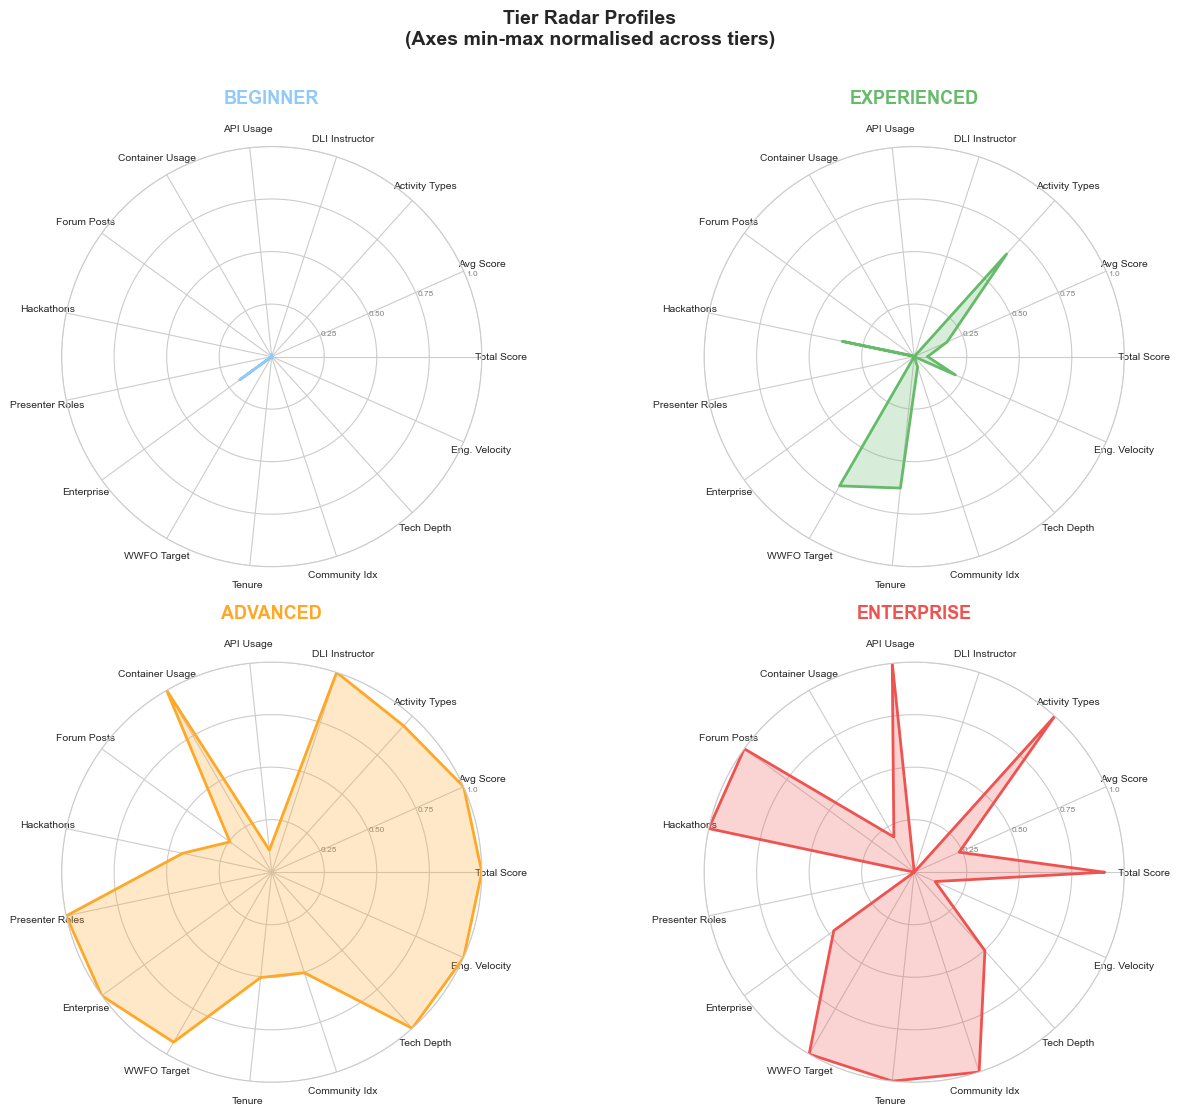

In [27]:
RADAR_FEATURES = [
    'total_score', 'avg_score', 'distinct_activity_types',
    'dli_instructor_led', 'api_count', 'container_count',
    'forum_count', 'hackathon_count', 'presenter_role_count',
    'is_enterprise', 'is_wwfo_targeted', 'tenure_days',
    'community_index', 'technical_depth', 'engagement_velocity',
]
RADAR_LABELS = [
    'Total Score', 'Avg Score', 'Activity Types',
    'DLI Instructor', 'API Usage', 'Container Usage',
    'Forum Posts', 'Hackathons', 'Presenter Roles',
    'Enterprise', 'WWFO Target', 'Tenure',
    'Community Idx', 'Tech Depth', 'Eng. Velocity',
]

means = df_labeled.groupby('tier')[RADAR_FEATURES].mean()
# Min-max normalise per feature across tiers so all axes are [0, 1]
means_norm = (means - means.min()) / (means.max() - means.min() + 1e-9)

N = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(2, 2, figsize=(13, 11), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, tier in zip(axes, TIER_ORDER):
    vals = means_norm.loc[tier].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=TIER_COLORS[tier], linewidth=2)
    ax.fill(angles, vals, color=TIER_COLORS[tier], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, size=7.5)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], size=6, color='grey')
    ax.set_ylim(0, 1)
    ax.set_title(tier.upper(), size=13, fontweight='bold',
                 color=TIER_COLORS[tier], pad=15)

plt.suptitle('Tier Radar Profiles\n(Axes min-max normalised across tiers)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Violin Plots — Within-Tier Distributions

The bar charts in the base notebook show *mean* feature values per tier, which is useful but hides the distribution shape. A violin plot combines a **box plot** (median, IQR, whiskers) with a **kernel density estimate** (KDE) that shows the full shape of the distribution. This is critical for understanding:

- **Skewness**: are most members of a tier concentrated at low values with a long tail of high performers?
- **Bimodality**: are there sub-populations within a tier?
- **Overlap**: how much do distributions of adjacent tiers overlap, indicating soft boundaries?

For clarity, raw values are log1p-transformed before plotting to compress the extreme tails. The six features shown were selected to highlight the most diagnostic differences between tiers.

In [ ]:
VIOLIN_FEATURES = [
    ('total_score',       'Total Score (log1p)'),
    ('dli_instructor_led','DLI Instructor-Led (log1p)'),
    ('api_count',         'API Count (log1p)'),
    ('technical_depth',   'Technical Depth Index (log1p)'),
    ('community_index',   'Community Index (log1p)'),
    ('engagement_velocity','Engagement Velocity (log1p)'),
]

np.random.seed(SEED)
# Sample for speed — violin KDE is slow on 9M rows
viol_sample = df_labeled.sample(n=min(200_000, len(df_labeled)), random_state=SEED).copy()
for col, _ in VIOLIN_FEATURES:
    viol_sample[col] = np.log1p(viol_sample[col].clip(lower=0))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (col, title) in zip(axes.flatten(), VIOLIN_FEATURES):
    data  = [viol_sample.loc[viol_sample['tier'] == t, col].values for t in TIER_ORDER]
    parts = ax.violinplot(data, positions=range(len(TIER_ORDER)),
                          showmedians=True, showextrema=True)
    for i, (pc, tier) in enumerate(zip(parts['bodies'], TIER_ORDER)):
        pc.set_facecolor(TIER_COLORS[tier])
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('black')
    ax.set_xticks(range(len(TIER_ORDER)))
    ax.set_xticklabels(TIER_ORDER, rotation=15, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('log1p(value)')

plt.suptitle('Violin Plots — Feature Distributions by Developer Tier\n(200 k sample, log1p scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Normalized Centroid Heatmap

The heatmap offers a compact, scannable overview of how each tier's centroid compares across all features. Each cell shows the **min-max normalised centroid value** for a (tier, feature) pair:

- A value of **1.0 (dark colour)** means this tier has the highest centroid value for that feature across all four tiers
- A value of **0.0 (light/white)** means this tier has the lowest centroid value for that feature

This view is particularly powerful for identifying **diagnostic features** — those that show extreme contrast between tiers (e.g., one tier is 1.0 and all others are near 0.0). Features with uniform values across tiers contribute little to cluster separation and might be candidates for removal in a future feature selection pass.

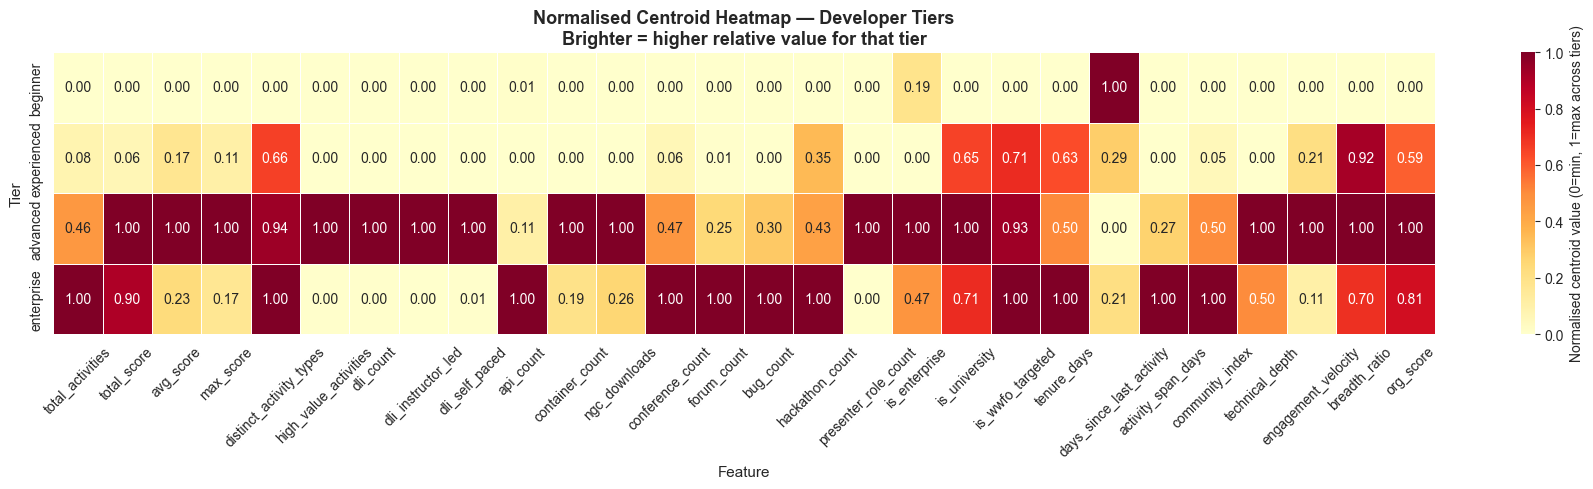

In [21]:
HEATMAP_FEATURES = [
    'total_activities', 'total_score', 'avg_score', 'max_score',
    'distinct_activity_types', 'high_value_activities',
    'dli_count', 'dli_instructor_led', 'dli_self_paced',
    'api_count', 'container_count', 'ngc_downloads',
    'conference_count', 'forum_count', 'bug_count',
    'hackathon_count', 'presenter_role_count',
    'is_enterprise', 'is_university', 'is_wwfo_targeted',
    'tenure_days', 'days_since_last_activity', 'activity_span_days',
    'community_index', 'technical_depth', 'engagement_velocity',
    'breadth_ratio', 'org_score',
]

heat_means = df_labeled.groupby('tier')[HEATMAP_FEATURES].mean().loc[TIER_ORDER]
heat_norm  = (heat_means - heat_means.min()) / (heat_means.max() - heat_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heat_norm,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.2f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Normalised centroid value (0=min, 1=max across tiers)'},
)
ax.set_title('Normalised Centroid Heatmap — Developer Tiers\n'
             'Brighter = higher relative value for that tier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Tier', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Activity Composition — Stacked Bar Chart

This chart answers a different question than the previous ones: *what does a typical developer in each tier actually spend their time doing?* Rather than showing absolute activity counts, it shows the **proportional composition of each tier's total activity** across activity categories. This reveals whether, for example, the enterprise tier's score comes primarily from DLI training vs. API usage vs. container downloads.

The activity categories are collapsed from the raw features into five high-level buckets:
- **Training (DLI)**: `dli_instructor_led` + `dli_self_paced`
- **API & NGC**: `api_count` + `ngc_downloads`
- **Containers & Models**: `container_count` + `model_count` + `helm_count`
- **Community**: `forum_count` + `bug_count` + `hackathon_count` + `conference_count` + `presenter_role_count`
- **Webinars**: `webinar_count`

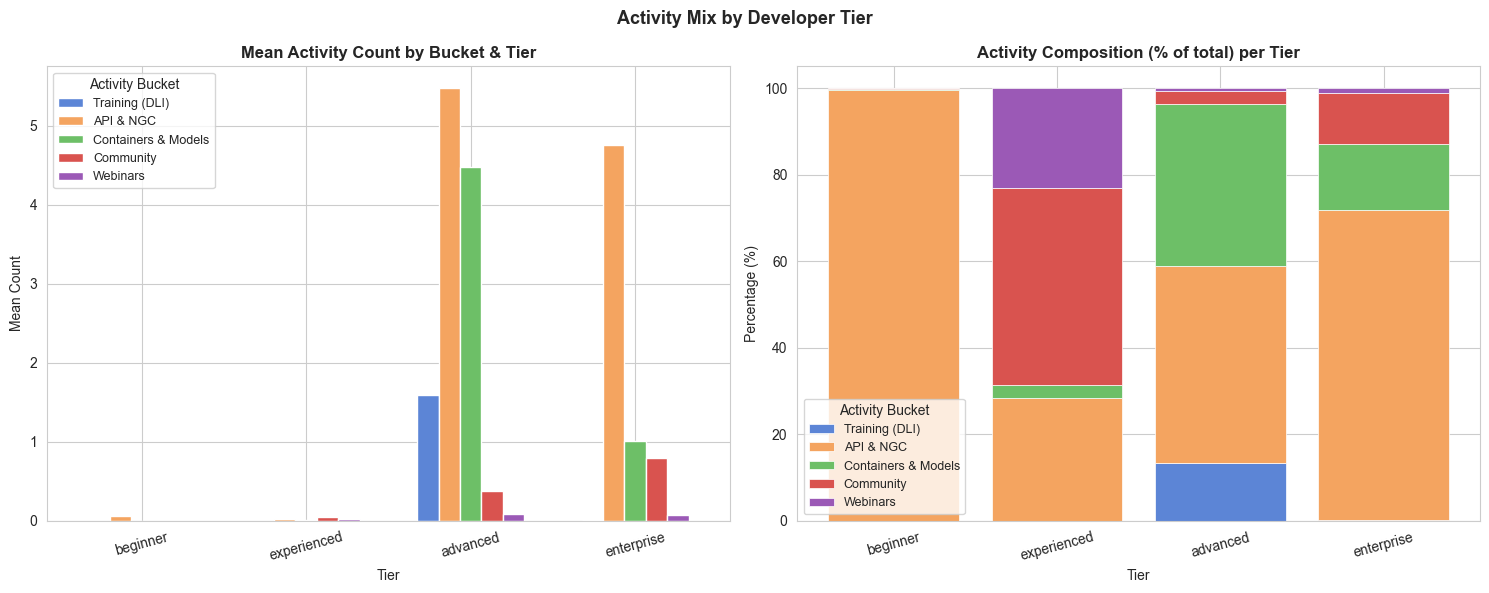


Activity composition (%) per tier:


,Training (DLI),API & NGC,Containers & Models,Community,Webinars
beginner,0.00,99.50,0.20,0.20,0.10
experienced,0.00,28.40,3.00,45.40,23.20
advanced,13.20,45.70,37.30,3.10,0.70
enterprise,0.10,71.80,15.10,11.90,1.10


In [22]:
ACTIVITY_BUCKETS = {
    'Training (DLI)':       ['dli_instructor_led', 'dli_self_paced'],
    'API & NGC':            ['api_count', 'ngc_downloads'],
    'Containers & Models':  ['container_count', 'model_count', 'helm_count'],
    'Community':            ['forum_count', 'bug_count', 'hackathon_count',
                             'conference_count', 'presenter_role_count'],
    'Webinars':             ['webinar_count'],
}

bucket_means = pd.DataFrame(index=TIER_ORDER)
for bucket, cols in ACTIVITY_BUCKETS.items():
    existing = [c for c in cols if c in df_labeled.columns]
    # Sum across columns per row first (DataFrame.sum, axis=1 is valid),
    # then groupby tier and take the mean — avoids GroupBy.sum(axis=1) which
    # was removed in pandas 2.x
    row_sums = df_labeled[existing].sum(axis=1)
    bucket_means[bucket] = row_sums.groupby(df_labeled['tier']).mean().reindex(TIER_ORDER)

bucket_pct = bucket_means.div(bucket_means.sum(axis=1), axis=0) * 100

bucket_colors = ['#5C85D6', '#F4A460', '#6DBF67', '#D9534F', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bucket_means.plot(kind='bar', ax=axes[0], color=bucket_colors, width=0.65, edgecolor='white')
axes[0].set_title('Mean Activity Count by Bucket & Tier', fontweight='bold')
axes[0].set_xlabel('Tier'); axes[0].set_ylabel('Mean Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Activity Bucket', fontsize=9)

bottom = np.zeros(len(TIER_ORDER))
for col, color in zip(bucket_pct.columns, bucket_colors):
    axes[1].bar(TIER_ORDER, bucket_pct[col], bottom=bottom,
                label=col, color=color, edgecolor='white', linewidth=0.5)
    bottom += bucket_pct[col].values
axes[1].set_title('Activity Composition (% of total) per Tier', fontweight='bold')
axes[1].set_xlabel('Tier'); axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Activity Bucket', fontsize=9)

plt.suptitle('Activity Mix by Developer Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nActivity composition (%) per tier:')
display(bucket_pct.round(1))

## Section 9 — Deep Insights

Visualizations show *what* the clusters look like. This section goes deeper to answer *why* the clustering works the way it does and *what actions* follow from the tier assignments.

### Sub-sections
1. **F-statistic Feature Importance** — which features do the most work in separating the four tiers?
2. **Engagement Gap Analysis** — how far is the average developer in each tier from the next tier up?
3. **Tier Distribution by Organization Type** — how does tier membership break down across enterprise, university, startup, and unaffiliated developers?

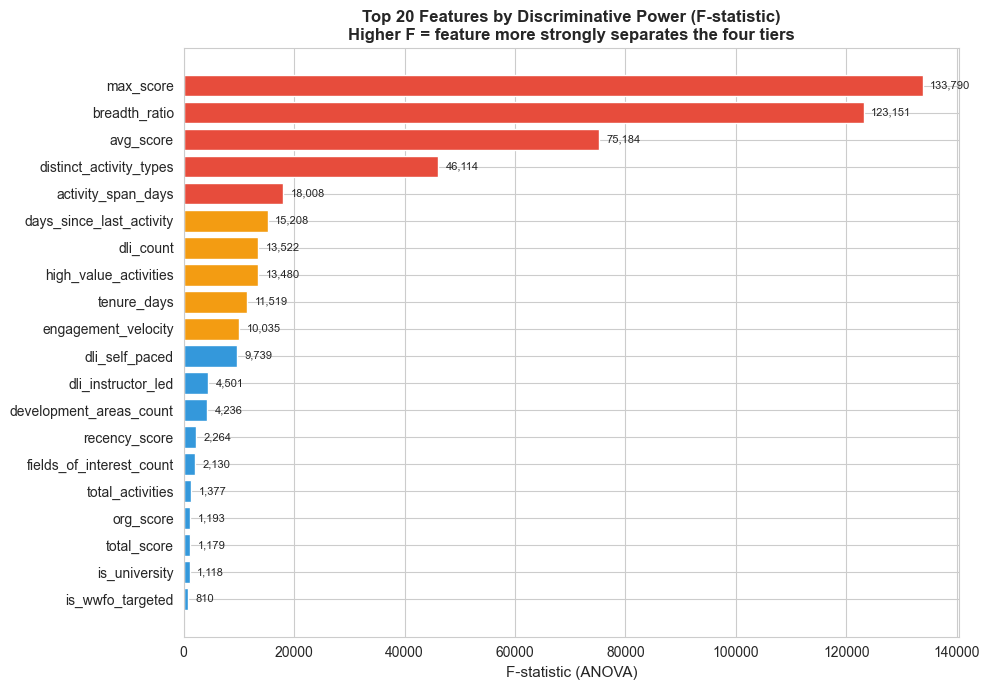

Top 10 most discriminative features:
   1. max_score                            F=   133,790
   2. breadth_ratio                        F=   123,151
   3. avg_score                            F=    75,184
   4. distinct_activity_types              F=    46,114
   5. activity_span_days                   F=    18,008
   6. days_since_last_activity             F=    15,208
   7. dli_count                            F=    13,522
   8. high_value_activities                F=    13,480
   9. tenure_days                          F=    11,519
  10. engagement_velocity                  F=    10,035


In [23]:
# F-statistic (one-way ANOVA): high F = feature strongly separates at least one tier
# We use a 100 k sample for speed; results are stable at this size
np.random.seed(SEED)
imp_sample = df_labeled.sample(n=min(100_000, len(df_labeled)), random_state=SEED)

f_stats = {}
for col in ADV_FEATURE_COLS:
    groups = [imp_sample.loc[imp_sample['tier'] == t, col].dropna().values
              for t in TIER_ORDER]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) == N_CLUSTERS:
        f_val, p_val = f_oneway(*groups)
        f_stats[col] = f_val

f_series = pd.Series(f_stats).sort_values(ascending=False)
top_n = 20
f_top = f_series.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#E74C3C' if v > f_top.quantile(0.75) else '#F39C12'
              if v > f_top.quantile(0.50) else '#3498DB' for v in f_top.values]
bars = ax.barh(f_top.index[::-1], f_top.values[::-1], color=colors_imp[::-1], edgecolor='white')
ax.set_xlabel('F-statistic (ANOVA)', fontsize=11)
ax.set_title(f'Top {top_n} Features by Discriminative Power (F-statistic)\n'
             'Higher F = feature more strongly separates the four tiers',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, f_top.values[::-1]):
    ax.text(bar.get_width() + f_top.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 most discriminative features:')
for i, (feat, fval) in enumerate(f_series.head(10).items(), 1):
    print(f'  {i:2d}. {feat:35s}  F={fval:>10,.0f}')

### Engagement Gap Analysis — Distance to the Next Tier

Clustering tells us *where* a developer currently sits, but a key business question is: *how far is each developer from graduating to the next tier?* This analysis computes the **Euclidean distance in scaled feature space** between each developer's feature vector and the centroid of the tier immediately above their current tier.

- A **beginner** is compared to the **experienced** centroid
- An **experienced** developer is compared to the **advanced** centroid
- An **advanced** developer is compared to the **enterprise** centroid
- **Enterprise** developers have no tier above them; this group is excluded from the gap analysis

A smaller distance indicates the developer is already close to the boundary of the next tier — they may be on the cusp of organic advancement and could respond well to a targeted nudge. A larger distance indicates deeper structural differences that would require more investment to overcome.

The resulting distribution reveals whether each tier has a *long tail* of developers far from advancement (suggesting many would need substantial engagement before upgrading) or a *concentrated distribution* (suggesting most members are within reach of the next tier).

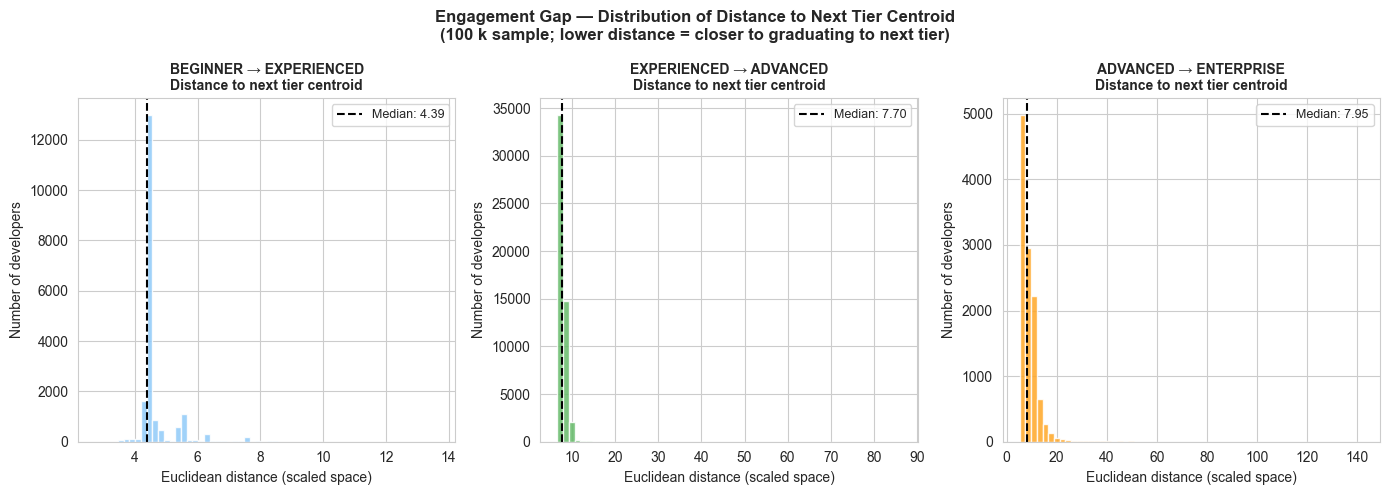

Median engagement gap by tier:
  beginner     -> experienced   median dist=4.391  p25=4.391  p75=4.391
  experienced  -> advanced      median dist=7.705  p25=7.361  p75=8.061
  advanced     -> enterprise    median dist=7.951  p25=6.891  p75=10.138


In [24]:
TIER_PROGRESSION = {
    'beginner':   'experienced',
    'experienced':'advanced',
    'advanced':   'enterprise',
}

# Build centroid lookup by tier name in scaled space
centroid_scaled = {}
for cid, tier_name in cluster_label_map.items():
    centroid_scaled[tier_name] = kmeans.cluster_centers_[cid]

np.random.seed(SEED)
gap_sample_size = min(100_000, len(X_scaled))
gap_idx = np.random.choice(len(X_scaled), size=gap_sample_size, replace=False)
X_gap     = X_scaled[gap_idx]
labels_gap = labels[gap_idx]

gaps = {}
for current_tier, next_tier in TIER_PROGRESSION.items():
    mask = labels_gap == current_tier
    if mask.sum() == 0:
        continue
    diff = X_gap[mask] - centroid_scaled[next_tier]
    dist = np.linalg.norm(diff, axis=1)
    gaps[current_tier] = dist

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, (tier, dist) in zip(axes, gaps.items()):
    next_t = TIER_PROGRESSION[tier]
    ax.hist(dist, bins=60, color=TIER_COLORS[tier], edgecolor='white', alpha=0.85)
    ax.axvline(np.median(dist), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {np.median(dist):.2f}')
    ax.set_title(f'{tier.upper()} → {next_t.upper()}\nDistance to next tier centroid',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Euclidean distance (scaled space)')
    ax.set_ylabel('Number of developers')
    ax.legend(fontsize=9)

plt.suptitle('Engagement Gap — Distribution of Distance to Next Tier Centroid\n'
             '(100 k sample; lower distance = closer to graduating to next tier)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median engagement gap by tier:')
for tier, dist in gaps.items():
    next_t = TIER_PROGRESSION[tier]
    print(f'  {tier:12s} -> {next_t:12s}  median dist={np.median(dist):.3f}  '
          f'p25={np.percentile(dist,25):.3f}  p75={np.percentile(dist,75):.3f}')

### Tier Distribution by Organization Type

The organizational context of a developer (enterprise, university, startup, or unaffiliated) is likely to correlate strongly with which tier they land in — but this correlation has not been explicitly visualised in the base notebook. This section computes the tier distribution within each organization type and displays it as a 100%-stacked bar chart.

This answers questions like:
- What fraction of enterprise-affiliated developers are in the *enterprise* tier? (If low, enterprise targeting may need refinement)
- Are university developers concentrated in *beginner* or *experienced* tiers?
- Do startup developers show more diverse engagement than their enterprise counterparts?

An **org_type** column is derived from the four binary indicator columns: a developer is classified into exactly one category based on their account flags (enterprise takes priority, then university, then startup, then individual/unaffiliated).

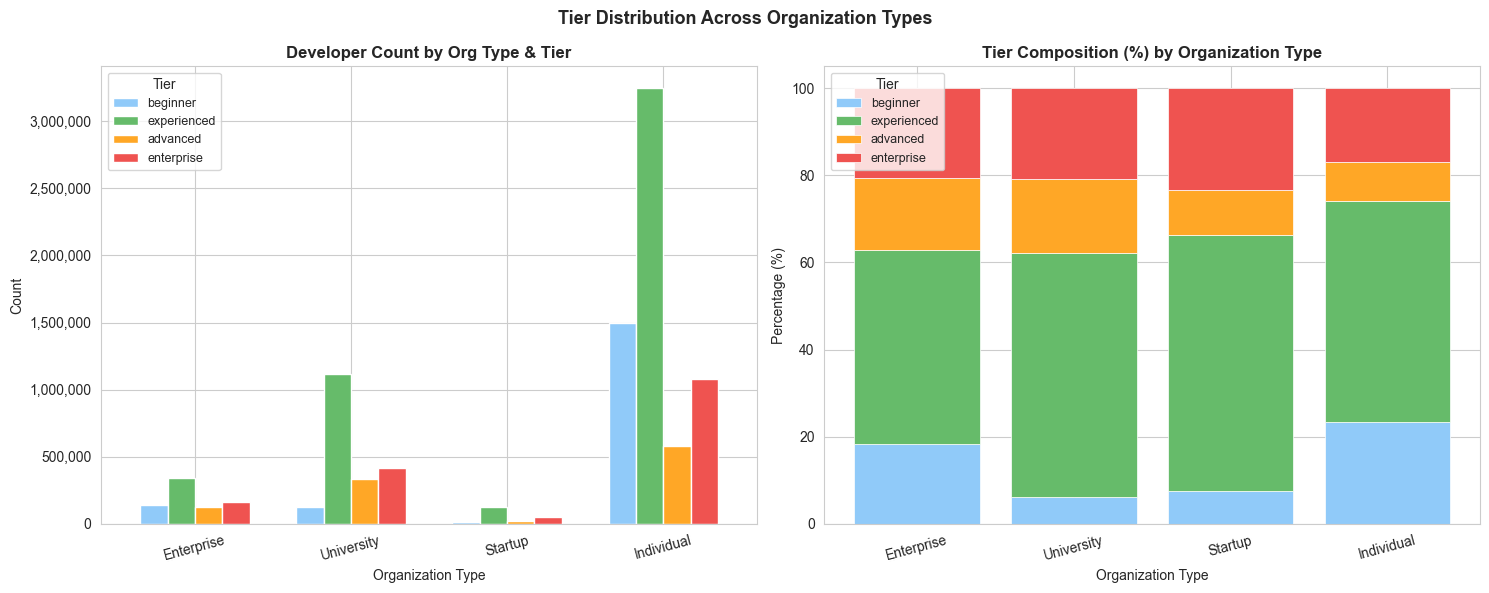

Tier composition (%) per organization type:


tier,beginner,experienced,advanced,enterprise
org_type,,,,
Enterprise,18.40,44.30,16.50,20.70
University,6.20,55.90,16.90,20.90
Startup,7.50,58.80,10.30,23.40
Individual,23.40,50.70,9.10,16.80


In [25]:
def assign_org_type(row):
    if row['is_enterprise'] == 1:
        return 'Enterprise'
    elif row['is_university'] == 1:
        return 'University'
    elif row['is_startup'] == 1:
        return 'Startup'
    else:
        return 'Individual'

df_labeled['org_type'] = df_labeled.apply(assign_org_type, axis=1)

ORG_ORDER  = ['Enterprise', 'University', 'Startup', 'Individual']
ORG_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#95A5A6']

org_tier = pd.crosstab(df_labeled['org_type'], df_labeled['tier'])[TIER_ORDER]
org_tier_pct = org_tier.div(org_tier.sum(axis=1), axis=0) * 100
org_tier_pct = org_tier_pct.reindex(ORG_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

org_tier.reindex(ORG_ORDER).plot(
    kind='bar', ax=axes[0],
    color=[TIER_COLORS[t] for t in TIER_ORDER],
    width=0.7, edgecolor='white',
)
axes[0].set_title('Developer Count by Org Type & Tier', fontweight='bold')
axes[0].set_xlabel('Organization Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Tier', fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

bottom = np.zeros(len(ORG_ORDER))
for tier, tc in zip(TIER_ORDER, [TIER_COLORS[t] for t in TIER_ORDER]):
    vals = org_tier_pct[tier].values
    axes[1].bar(ORG_ORDER, vals, bottom=bottom, label=tier, color=tc, edgecolor='white', linewidth=0.5)
    bottom += vals
axes[1].set_title('Tier Composition (%) by Organization Type', fontweight='bold')
axes[1].set_xlabel('Organization Type'); axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Tier', fontsize=9)

plt.suptitle('Tier Distribution Across Organization Types', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tier composition (%) per organization type:')
display(org_tier_pct.round(1))

In [26]:
SUMMARY_COLS = [
    'total_activities', 'total_score', 'avg_score', 'max_score',
    'dli_count', 'dli_instructor_led', 'api_count', 'container_count',
    'forum_count', 'hackathon_count',
    'is_enterprise', 'is_wwfo_targeted',
    'tenure_days', 'days_since_last_activity',
    'community_index', 'technical_depth', 'engagement_velocity', 'breadth_ratio',
]

summary = df_labeled.groupby('tier')[SUMMARY_COLS].mean().round(2).loc[TIER_ORDER]
summary.insert(0, 'count', df_labeled.groupby('tier').size().reindex(TIER_ORDER))
summary.insert(1, 'pct_%', (df_labeled.groupby('tier').size() / len(df_labeled) * 100).round(1).reindex(TIER_ORDER))

print('=== Advanced Developer Tier Summary ===')
display(summary)

print('\n=== New Feature Means by Tier ===')
display(df_labeled.groupby('tier')[['community_index','technical_depth','engagement_velocity','breadth_ratio','org_score']]
        .mean().round(3).loc[TIER_ORDER])

=== Advanced Developer Tier Summary ===


,count,pct_%,total_activities,total_score,avg_score,max_score,dli_count,dli_instructor_led,api_count,container_count,forum_count,hackathon_count,is_enterprise,is_wwfo_targeted,tenure_days,days_since_last_activity,community_index,technical_depth,engagement_velocity,breadth_ratio
tier,,,,,,,,,,,,,,,,,,,,
beginner,1779589,19.00,0.06,0.01,0.01,0.01,0.00,0.00,0.05,0.00,0.00,0.00,0.08,0.07,6.26,1790.59,0.00,0.05,0.01,0.03
experienced,4828899,51.50,2.17,4.98,2.20,2.68,0.00,0.00,0.02,0.00,0.00,0.00,0.07,0.20,879.95,933.78,0.09,0.02,4.15,1.58
advanced,1067915,11.40,12.18,78.03,12.84,24.61,1.59,0.31,0.38,3.81,0.01,0.00,0.12,0.24,706.24,587.80,0.82,9.00,19.33,1.72
enterprise,1705087,18.20,26.22,70.61,3.01,4.09,0.01,0.00,3.45,0.74,0.05,0.00,0.09,0.25,1394.97,842.62,1.62,4.54,2.12,1.20



=== New Feature Means by Tier ===


,community_index,technical_depth,engagement_velocity,breadth_ratio,org_score
tier,,,,,
beginner,0.00,0.05,0.01,0.03,0.53
experienced,0.09,0.02,4.15,1.58,1.10
advanced,0.82,9.00,19.33,1.72,1.49
enterprise,1.62,4.54,2.12,1.20,1.30


## Cluster Interpretation — Extended Notes

### Beginner
Developers in this tier have had minimal engagement with the NVIDIA ecosystem. Their `engagement_velocity` and `technical_depth` scores are near zero, indicating either a very recent join date or a prolonged period of inactivity. The `days_since_last_activity` value is the highest of all tiers, which is the dominant signal driving their cluster membership. These developers have not yet engaged with DLI courses, APIs, or containers. They represent the largest share of registered developers and are the primary target for **activation campaigns** — email sequences, tutorial recommendations, and low-friction onboarding resources.

### Experienced
Developers who are actively building with NVIDIA tools. They show elevated `api_count`, `container_count`, and `dli_self_paced` values relative to beginners, and their `engagement_velocity` is higher — they earn score at a faster rate per active day. The `breadth_ratio` for this group is notable: they spread their activity across multiple types rather than specialising. These developers are well-positioned to be converted to the *advanced* tier with targeted deep-dive content recommendations — particularly instructor-led DLI offerings which they have not yet utilised.

### Advanced
Highly engaged technical developers with deep investment in the NVIDIA stack. The distinguishing signals are `dli_instructor_led` completions, `presenter_role_count`, `hackathon_count`, `forum_count`, and `bug_count`. These activities all require significant time investment and indicate community leadership. Their `community_index` and `technical_depth` scores are the highest of any tier. These developers are power users and potential community advocates — the most effective engagement strategy involves recognition programs, early access to new products, and speaker opportunities at NVIDIA events.

### Enterprise
Developers affiliated with formal organisations: linked to an enterprise account and often flagged in the WWFO high-value target list. Their individual activity levels may not always be the highest, but their organisational context signals institutional adoption potential. The `org_score` composite is uniquely elevated for this tier. This group is the primary target for **enterprise sales motions**, partnership programs, and volume licensing conversations. Note that some enterprise developers have relatively low `technical_depth` scores — this may indicate a managerial or procurement role rather than a hands-on engineering role, and messaging should be adjusted accordingly.